In [32]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

# Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [33]:
# Dataset loads
df = pd.read_csv('previsao_de_renda.csv')
df = df.drop(columns=[ 'Unnamed: 0','id_cliente', 'data_ref'])
print("✅Dataset loaded successfully!")

print('='*163)
print("Dataset Visualization".center(163))
print('='*163)
display(df.head())

print('='*163)
print("Dataset Structure".center(163))
print('='*163)
display(df.info())

✅Dataset loaded successfully!
                                                                       Dataset Visualization                                                                       


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,F,False,True,0,Empresário,Secundário,Solteiro,Casa,26,6.602740,1.0,8060.34
1,M,True,True,0,Assalariado,Superior completo,Casado,Casa,28,7.183562,2.0,1852.15
2,F,True,True,0,Empresário,Superior completo,Casado,Casa,35,0.838356,2.0,2253.89
3,F,False,True,1,Servidor público,Superior completo,Casado,Casa,30,4.846575,3.0,6600.77
4,M,True,False,0,Assalariado,Secundário,Solteiro,Governamental,33,4.293151,1.0,6475.97


                                                                         Dataset Structure                                                                         
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sexo                   15000 non-null  object 
 1   posse_de_veiculo       15000 non-null  bool   
 2   posse_de_imovel        15000 non-null  bool   
 3   qtd_filhos             15000 non-null  int64  
 4   tipo_renda             15000 non-null  object 
 5   educacao               15000 non-null  object 
 6   estado_civil           15000 non-null  object 
 7   tipo_residencia        15000 non-null  object 
 8   idade                  15000 non-null  int64  
 9   tempo_emprego          12427 non-null  float64
 10  qt_pessoas_residencia  15000 non-null  float64
 11  renda                  15000 non-null  float64

None

In [34]:
# independent (X) and dependent (y) variables
X = df.drop(columns= 'renda')
y = df['renda']

print('='*154)
print("independent (X)".center(154))
print('='*154)
display(X.head(5))

print('='*154)
print("dependent (y)".center(154))
print('='*154)
display(y.head(5))

                                                                     independent (X)                                                                      


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia
0,F,False,True,0,Empresário,Secundário,Solteiro,Casa,26,6.602740,1.0
1,M,True,True,0,Assalariado,Superior completo,Casado,Casa,28,7.183562,2.0
2,F,True,True,0,Empresário,Superior completo,Casado,Casa,35,0.838356,2.0
3,F,False,True,1,Servidor público,Superior completo,Casado,Casa,30,4.846575,3.0
4,M,True,False,0,Assalariado,Secundário,Solteiro,Governamental,33,4.293151,1.0


                                                                      dependent (y)                                                                       


0    8060.34
1    1852.15
2    2253.89
3    6600.77
4    6475.97
Name: renda, dtype: float64

In [35]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

# Dummies
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1)

# Corrects NaN generated by align
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

In [36]:
# Ridge
results_ridge = []
alphas = [0, 0.001, 0.005, 0.01, 0.05]

for alpha in alphas:
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    r2_ridge = r2_score(y_test, y_pred)
    rmse_ridge = mean_squared_error(y_test, y_pred, squared=False)

    results_ridge.append((alpha, r2_ridge, rmse_ridge))

# Results Ridge
df_ridge = pd.DataFrame(results_ridge, columns=['alpha', 'R2', 'RMSE'])
df_ridge.sort_values(by='RMSE')


,alpha,R2,RMSE
0,0.000,0.268458,7019.666373
1,0.001,0.268458,7019.666373
2,0.005,0.268458,7019.666374
3,0.010,0.268458,7019.666375
4,0.050,0.268458,7019.666384


---

In [37]:
# Lasso
results_lasso = []
alphas = [0, 0.001, 0.005, 0.01, 0.05]

for alpha in alphas:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=10000))
    ])

    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)

    r2_lasso = r2_score(y_test, y_pred)
    rmse_lasso = mean_squared_error(y_test, y_pred, squared=False)

    results_lasso.append((alpha, r2_lasso, rmse_lasso))

# Results Lasso
df_lasso = (
    pd.DataFrame(results_lasso, columns=['alpha', 'R2', 'RMSE'])
    .sort_values(by='RMSE')
)

df_lasso


c:\Users\Littl\anaconda3\Lib\site-packages\sklearn\pipeline.py:405: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
c:\Users\Littl\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Littl\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.859e+11, tolerance: 7.723e+07 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.

,alpha,R2,RMSE
4,0.050,0.268458,7019.666037
3,0.010,0.268458,7019.666255
2,0.005,0.268458,7019.666311
1,0.001,0.268458,7019.666360
0,0.000,0.268458,7019.666373


---

In [38]:
# Stepwise
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.05, 
                       threshold_out=0.05, 
                       verbose=True):

    included = list(initial_list)

    while True:
        changed = False

        # FORWARD STEP
        excluded = list(set(X.columns) - set(included))
        new_pvalues = pd.Series(index=excluded, dtype=float)

        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pvalues[new_column] = model.pvalues[new_column]

        if not new_pvalues.empty:
            best_pvalue = new_pvalues.min()
            if best_pvalue < threshold_in:
                best_feature = new_pvalues.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f'Add  {best_feature:30} with p-value {best_pvalue:.6}')

        # BACKWARD STEP
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]  # remove intercept
        worst_pvalue = pvalues.max()

        if worst_pvalue > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True
            if verbose:
                print(f'Drop {worst_feature:30} with p-value {worst_pvalue:.6}')

        if not changed:
            break

    return included

In [39]:
# Float type
X_train_sw = X_train.astype(float)
X_test_sw  = X_test.astype(float)

# Log transformation 
y_train_log = np.log1p(y_train)

# Select the best variables
selected_features = stepwise_selection(X_train_sw, y_train)

display(selected_features)

# X_train stepwise (the best variables)
X_final = X_train_sw[selected_features]
X_final = sm.add_constant(X_final)

# OLS regression
model = sm.OLS(y_train_log, X_final).fit()

model.summary()

Add  tempo_emprego                  with p-value 0.0
Add  sexo_M                         with p-value 2.29624e-266
Add  tipo_renda_Pensionista         with p-value 3.34101e-56
Add  tipo_renda_Empresário          with p-value 1.77532e-07
Add  educacao_Superior completo     with p-value 1.16378e-05
Add  idade                          with p-value 2.31163e-06
Add  estado_civil_Solteiro          with p-value 0.0213471


['tempo_emprego',
 'sexo_M',
 'tipo_renda_Pensionista',
 'tipo_renda_Empresário',
 'educacao_Superior completo',
 'idade',
 'estado_civil_Solteiro']

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  renda   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     836.6
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:55:56   Log-Likelihood:                -12217.
No. Observations:               11250   AIC:                         2.445e+04
Df Residuals:                   11242   BIC:                         2.451e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          7.2053      0.035    203.846      0.000       7.136       7.275
tempo_emprego                  0.0613      0.001     52.494      0.000       0.059       0.064
sexo_M                         0.8018      0.015     53.642      0.000       0.773       0.831
tipo_renda_Pensionista         0.2874      0.027     10.506      0.000       0.234       0.341
tipo_renda_Empresário          0.1550      0.017      9.311      0.000       0.122       0.188
educacao_Superior completo     0.1324      0.014      9.250      0.000       0.104       0.160
idade                          0.0049      0.001      5.951      0.000       0.003       0.006
estado_civil_Solteiro         -0.0379      0.021     -1.809      0.070      -0.079       0.003
==============================================================================
Omnibus:                        0.679   Durbin-Watson:                   1.978
Prob(Omnibus):                  0.712   Jarque-Bera (JB):                0.710
Skew:                           0.009   Prob(JB):                        0.701
Kurtosis:                       2.965   Cond. No.                         259.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
# X_test stepwise (the best variables)
X_test_sw = X_test[selected_features]
X_test_sw = sm.add_constant(X_test_sw)

# log predict 
y_pred_log = model.predict(X_test_sw)
y_pred_log = y_pred_log.astype(float)

# exponential predict
y_pred = np.expm1(y_pred_log)

# Predict type
y_pred_log.dtype

# Results stepwise
r2_stepwise = r2_score(y_test, y_pred)
rmse_stepwise = mean_squared_error(y_test, y_pred, squared=False)

template = "The model {a}\nR²={r2:.2f}\nRMSE={RMSE:.2f}\n" 

print(template.format(a="Stepwise", r2=r2_stepwise, RMSE=rmse_stepwise))

The model Stepwise
R²=0.24
RMSE=7139.44



In [41]:
# Non - Linear Model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2_randomforest = r2_score(y_test, y_pred)
rmse_randomforest = mean_squared_error(y_test, y_pred, squared=False)
scores_randomforest = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

template = "The model {a}\nR²= {r2:.2f}\nRMSE= {RMSE:.2f}\nCross-validation = {cv:.2f}"

print(template.format(
    a="Random Forest",
    r2=r2_randomforest,
    RMSE=rmse_randomforest,
    cv=scores_randomforest.mean()
))

The model Random Forest
R²= 0.41
RMSE= 6300.86
Cross-validation = 0.50


In [42]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

r2_grid = r2_score(y_test, y_pred)
rmse_grid = np.sqrt(mean_squared_error(y_test, y_pred))
scores_grid = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')

template = (
    "The model {a}\n"
    "Best params = {params}\n"
    "R² = {r2:.2f}\n"
    "RMSE = {rmse:.2f}\n"
    "Cross-validation = {cv:.2f}"
)

print(template.format(
    a="Random Forest GridSearchCV",
    params=grid.best_params_,
    r2=r2_grid,
    rmse=rmse_grid,
    cv=scores_grid.mean()
))


The model Random Forest GridSearchCV
Best params = {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}
R² = 0.42
RMSE = 6252.58
Cross-validation = 0.51


In [43]:
# Model Comparison
print('='*33)
print("Ridge Model".center(33))
print('='*33)

display(df_ridge.sort_values(by='RMSE'))

print('='*33)
print("Lasso Model".center(33))
print('='*33)

display(df_lasso)

print('='*33)
print("Stepwise Model".center(33))
print('='*33)

template = "The model {a}\nR²= {r2:.2f}\nRMSE= {RMSE:.2f}\n" 

print(template.format(a="Stepwise", r2=r2_stepwise, RMSE=rmse_stepwise))

print('='*33)
print("Random Forest".center(33))
print('='*33)

template = "The model {a}\nR²= {r2:.2f}\nRMSE= {RMSE:.2f}\nCross-validation = {cv:.2f}"

print(template.format(
    a="Random Forest",
    r2=r2_randomforest,
    RMSE=rmse_randomforest,
    cv=scores_randomforest.mean()
))

print('='*33)
print("Random Forest GridSearchCV".center(33))
print('='*33)
print(template.format(
    a="Random Forest GridSearchCV",
    r2=r2_grid,
    RMSE=rmse_grid,
    cv=scores_grid.mean()
))

print('='*180)
print("Best Model🏆".center(180))
print('='*180)


print("""    
The Random Forest model optimized with GridSearchCV proved to be the most effective approach, outperforming linear models and capturing non-linear relationships in customer income.
This result highlights the importance of non-linear patterns in the data, which were better modeled by tree-based methods.
Despite solid performance, further improvements can be achieved through feature engineering, outlier handling, and more advanced algorithms.
      """)

           Ridge Model           


,alpha,R2,RMSE
0,0.000,0.268458,7019.666373
1,0.001,0.268458,7019.666373
2,0.005,0.268458,7019.666374
3,0.010,0.268458,7019.666375
4,0.050,0.268458,7019.666384


           Lasso Model           


,alpha,R2,RMSE
4,0.050,0.268458,7019.666037
3,0.010,0.268458,7019.666255
2,0.005,0.268458,7019.666311
1,0.001,0.268458,7019.666360
0,0.000,0.268458,7019.666373


          Stepwise Model         
The model Stepwise
R²= 0.24
RMSE= 7139.44

          Random Forest          
The model Random Forest
R²= 0.41
RMSE= 6300.86
Cross-validation = 0.50
    Random Forest GridSearchCV   
The model Random Forest GridSearchCV
R²= 0.42
RMSE= 6252.58
Cross-validation = 0.51
                                                                                    Best Model🏆                                                                                     
    
The Random Forest model optimized with GridSearchCV proved to be the most effective approach, outperforming linear models and capturing non-linear relationships in customer income.
This result highlights the importance of non-linear patterns in the data, which were better modeled by tree-based methods.
Despite solid performance, further improvements can be achieved through feature engineering, outlier handling, and more advanced algorithms.
      


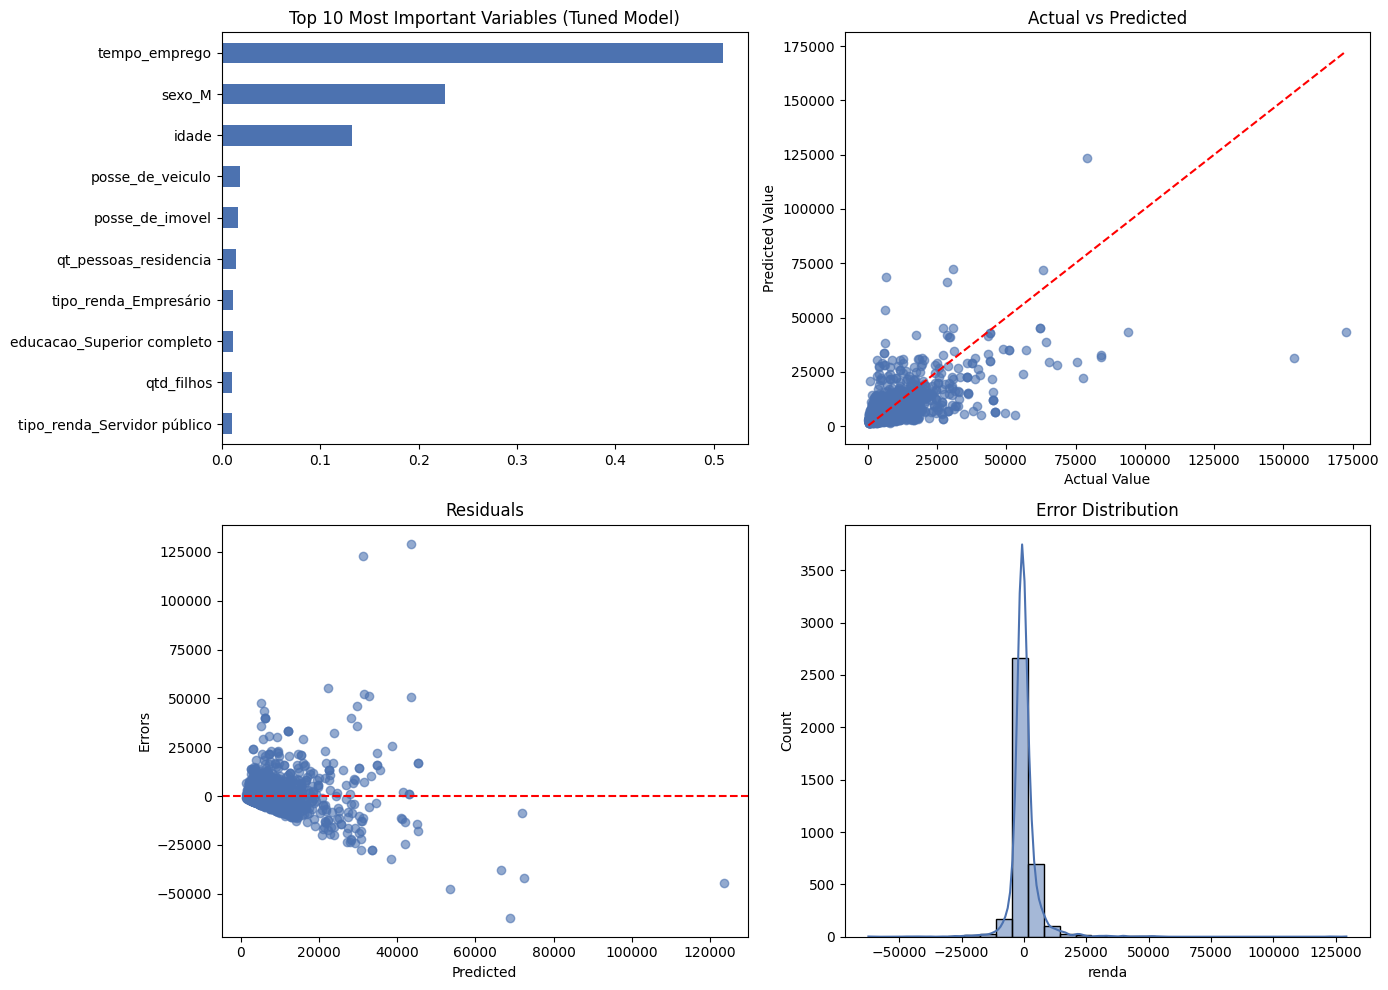

                                                                                      Insight💡📊                                                                                      
      
The model achieved solid performance (R² ≈ 0.42), accurately predicting low and medium income ranges where most observations are concentrated.
However, residual analysis shows systematic underestimation of high-income values and the presence of heteroscedasticity,
indicating increasing prediction uncertainty at higher income levels. Despite these limitations, the model provides valuable
insights—especially the importance of employment duration—and can be improved through target transformation, outlier treatment, and enhanced feature engineering.
      


<Figure size 640x480 with 0 Axes>

In [ ]:
# figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature Importance
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(
    kind='barh',
    color='#4C72B0',
    ax=axes[0, 0]
)

axes[0, 0].set_title("Top 10 Most Important Variables (Tuned Model)")
axes[0, 0].invert_yaxis()

# 2. Actual vs Predicted
axes[0, 1].scatter(y_test, y_pred, color='#4C72B0', alpha=0.6)
axes[0, 1].set_xlabel("Actual Value")
axes[0, 1].set_ylabel("Predicted Value")
axes[0, 1].set_title("Actual vs Predicted")

# line (diagonal)
axes[0, 1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

# 3. Residuals
resid = y_test - y_pred

axes[1, 0].scatter(y_pred, resid, color='#4C72B0', alpha=0.6)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Errors")
axes[1, 0].set_title("Residuals")

# 4. Error Distribution 
sns.histplot(resid, bins=30, kde=True, color='#4C72B0', ax=axes[1, 1])
axes[1, 1].set_title("Error Distribution")

# Layout
plt.tight_layout()
plt.savefig("dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

print('='*181)
print("Insight💡📊".center(181))
print('='*181)
print("""      
The model achieved solid performance (R² ≈ 0.42), accurately predicting low and medium income ranges where most observations are concentrated.
However, residual analysis shows systematic underestimation of high-income values and the presence of heteroscedasticity,
indicating increasing prediction uncertainty at higher income levels. Despite these limitations, the model provides valuable
insights—especially the importance of employment duration—and can be improved through target transformation, outlier treatment, and enhanced feature engineering.
      """)